<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/notebooks/DBSCAN_Anomaly_Detection_DuckDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlyRank — DBSCAN Content Anomaly Discovery with DuckDB



**Goal:** discover unusual content groups and sparse observations that may represent unexpected winners or failures.

**Interpretation:** DBSCAN labels sparse observations as `-1` (noise). Noise is not automatically bad content or a proven anomaly; review its metrics and business context.

This notebook defaults to all aggregated content rows, not all daily rows in Python. DBSCAN can be memory-intensive; use the optional row cap for exploratory runs if necessary.

In [1]:
%pip -q install duckdb huggingface_hub scikit-learn pandas numpy matplotlib seaborn

## 1. Hugging Face authentication

In Colab, add `HF_TOKEN` under Secrets and enable notebook access. The fallback uses a hidden prompt. Do not hard-code or share your token.

In [2]:
import os
from getpass import getpass

HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        HF_TOKEN = None
if not HF_TOKEN:
    HF_TOKEN = getpass("Hugging Face token (input hidden): ")
if not HF_TOKEN:
    raise ValueError("HF_TOKEN is required.")

Hugging Face token (input hidden): ··········


In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()
safe_token = HF_TOKEN.replace("'", "''")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{safe_token}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}
print("DuckDB ready:", TABLES["fact_daily"])

DuckDB ready: read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')


## 2. Aggregate the daily data in DuckDB

Features use recent and previous 30-day windows, plus 60-day ranking volatility. The `imp_prev30 >= 100` baseline filter reduces unstable percentage changes caused by tiny impression counts; change it if low-volume content is also important.

In [4]:
feature_sql = f'''
WITH bounds AS (
    SELECT MAX(report_date) AS end_d FROM {TABLES["fact_daily"]}
),
windowed AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        SUM(CASE WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS imp_last30,
        SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                  AND f.report_date > b.end_d - INTERVAL 60 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS imp_prev30,
        SUM(CASE WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_clicks, 0) ELSE 0 END) AS clk_last30,
        SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                  AND f.report_date > b.end_d - INTERVAL 60 DAY
                 THEN COALESCE(f.gsc_clicks, 0) ELSE 0 END) AS clk_prev30,
        AVG(CASE WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                 THEN f.gsc_avg_position END) AS pos_last30,
        AVG(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                  AND f.report_date > b.end_d - INTERVAL 60 DAY
                 THEN f.gsc_avg_position END) AS pos_prev30
    FROM {TABLES["fact_daily"]} f
    CROSS JOIN bounds b
    WHERE f.report_date > b.end_d - INTERVAL 60 DAY
    GROUP BY f.client_hash_id, f.content_hash_id
    HAVING SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                     AND f.report_date > b.end_d - INTERVAL 60 DAY
                    THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) >= 100
),
volatility AS (
    SELECT f.client_hash_id, f.content_hash_id,
           STDDEV_SAMP(f.gsc_avg_position) AS pos_volatility_60d
    FROM {TABLES["fact_daily"]} f
    CROSS JOIN bounds b
    WHERE f.report_date > b.end_d - INTERVAL 60 DAY
    GROUP BY f.client_hash_id, f.content_hash_id
),
qsignals AS (
    SELECT
        content_hash_id,
        ANY_VALUE(content_visible_query_count) AS visible_queries,
        ANY_VALUE(rare_impressions_share) AS rare_share,
        ANY_VALUE(anonymized_impressions_share) AS anon_share,
        MAX(impressions_90d) AS top_query_impressions,
        SUM(impressions_90d) AS kept_impressions
    FROM {TABLES["fact_query_90d"]}
    GROUP BY content_hash_id
)
SELECT w.*, v.pos_volatility_60d,
       q.visible_queries, q.rare_share, q.anon_share,
       q.top_query_impressions / NULLIF(q.kept_impressions, 0) AS top_query_share
FROM windowed w
LEFT JOIN volatility v
  ON w.client_hash_id = v.client_hash_id AND w.content_hash_id = v.content_hash_id
LEFT JOIN qsignals q ON w.content_hash_id = q.content_hash_id
'''
features = con.execute(feature_sql).df()
print(f"Aggregated content rows: {len(features):,}")
display(features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Aggregated content rows: 111,247


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,pos_volatility_60d,visible_queries,rare_share,anon_share,top_query_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,266.0,628.0,2.0,3.0,13.862869,11.948364,4.096234,14,0.043656,0.725102,0.162242
1,client_08a6a72ff48e62c0,content_4486e5efcc7b773f,1023.0,648.0,1.0,4.0,12.673794,9.741120,4.029277,10,0.041108,0.748594,0.347737
2,client_08a6a72ff48e62c0,content_44a3108ea1a95d57,2.0,260.0,0.0,0.0,2.500000,73.809185,26.885827,5,0.075630,0.043697,0.448473
3,client_08a6a72ff48e62c0,content_44c082bdb9a864ea,7056.0,7963.0,4.0,13.0,6.876839,7.088636,0.422063,23,0.004720,0.810897,0.167181
4,client_08a6a72ff48e62c0,content_44e3ef9fba240531,169.0,261.0,0.0,0.0,23.823962,26.559816,11.860009,4,0.246217,0.627235,0.500000


## 3. Engineer features and configure the run

Traffic counts are log-transformed because they are strongly skewed. IDs are kept for interpretation but are not used as model features. The optional row cap is only for exploration; leave it as `None` to use every aggregated row.

In [5]:
MAX_ROWS_FOR_DBSCAN = None  # e.g. 50000 for an exploratory run; None = all rows
RANDOM_STATE = 42

if features.empty:
    raise ValueError("No feature rows returned. Check access, schema, and date coverage.")

df = features.copy()
df["ctr_last30"] = df["clk_last30"] / df["imp_last30"].replace(0, np.nan)
df["ctr_prev30"] = df["clk_prev30"] / df["imp_prev30"].replace(0, np.nan)
df["position_change"] = df["pos_last30"] - df["pos_prev30"]
df["impressions_log_change"] = np.log1p(df["imp_last30"].clip(lower=0)) - np.log1p(df["imp_prev30"].clip(lower=0))
df["clicks_log_change"] = np.log1p(df["clk_last30"].clip(lower=0)) - np.log1p(df["clk_prev30"].clip(lower=0))
df["log_imp_last30"] = np.log1p(df["imp_last30"].clip(lower=0))
df["log_clk_last30"] = np.log1p(df["clk_last30"].clip(lower=0))
df["log_visible_queries"] = np.log1p(df["visible_queries"].clip(lower=0))
df["log_pos_volatility"] = np.log1p(df["pos_volatility_60d"].clip(lower=0))

feature_cols = [
    "log_imp_last30", "log_clk_last30", "ctr_last30", "ctr_prev30",
    "impressions_log_change", "clicks_log_change",
    "pos_last30", "pos_prev30", "position_change", "log_pos_volatility",
    "log_visible_queries", "rare_share", "anon_share", "top_query_share"
]
X_raw = df[feature_cols].replace([np.inf, -np.inf], np.nan)
all_missing = X_raw.columns[X_raw.isna().all()].tolist()
if all_missing:
    print("Dropping entirely missing features:", all_missing)
    X_raw = X_raw.drop(columns=all_missing)
    feature_cols = X_raw.columns.tolist()

valid = X_raw.notna().any(axis=1)
df, X_raw = df.loc[valid].copy(), X_raw.loc[valid].copy()
if MAX_ROWS_FOR_DBSCAN is not None and len(df) > MAX_ROWS_FOR_DBSCAN:
    keep_idx = df.sample(n=MAX_ROWS_FOR_DBSCAN, random_state=RANDOM_STATE).index
    df, X_raw = df.loc[keep_idx].copy(), X_raw.loc[keep_idx].copy()

print(f"Rows used: {len(df):,} | Features: {len(feature_cols)}")
display(X_raw.describe().T)

Rows used: 111,247 | Features: 14


,count,mean,std,min,25%,50%,75%,max
log_imp_last30,111247.0,5.975236,1.827259,0.0,4.882802,5.963579,7.16472,13.329399
log_clk_last30,111247.0,1.054725,1.181958,0.0,0.0,0.693147,1.791759,8.247482
ctr_last30,110087.0,0.003844,0.007767,0.0,0.0,0.001837,0.005306,1.0
ctr_prev30,111247.0,0.003314,0.00494,0.0,0.0,0.001742,0.004737,0.151261
impressions_log_change,111247.0,-0.59844,1.153758,-8.592486,-1.022626,-0.490588,0.00107,6.266008
clicks_log_change,111247.0,-0.084331,0.739184,-4.941642,-0.570545,0.0,0.223144,4.736198
pos_last30,110087.0,20.518548,17.892419,0.0,7.621376,13.604974,27.889071,579.0
pos_prev30,111247.0,19.876609,15.221839,0.344381,8.555058,14.677241,26.837758,92.287366
position_change,110087.0,0.704844,10.810775,-81.943678,-3.719792,-0.018191,4.061199,562.625412
log_pos_volatility,111246.0,2.177078,0.798896,0.151144,1.604047,2.301302,2.811789,4.726916


In [6]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

imputer = SimpleImputer(strategy="median", keep_empty_features=True)
X_imputed = imputer.fit_transform(X_raw)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)
print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (111247, 14)


## 4. Select `eps` with a k-distance plot

`min_samples` is the number of neighbors needed for a dense region. `eps` is the neighborhood radius. There is no universal best value: use the plot and sensitivity table together, and report the final setting.

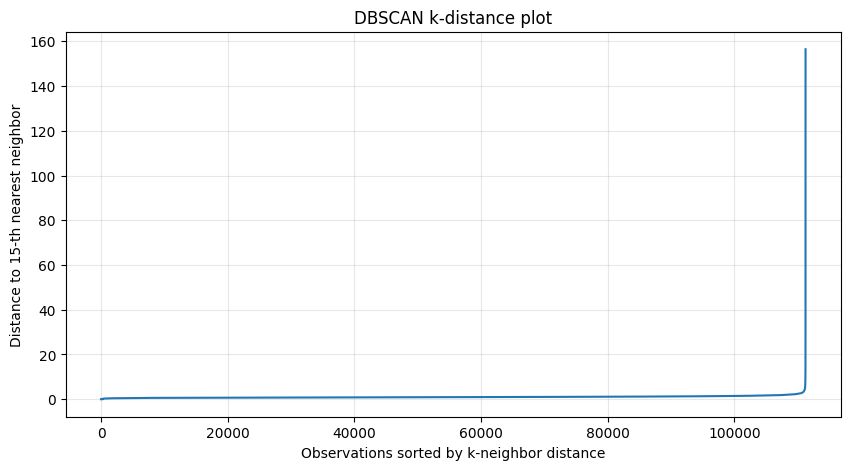

0.50    0.928086
0.75    1.157166
0.80    1.230985
0.85    1.326691
0.90    1.464713
0.95    1.712678
0.99    2.435647
dtype: float64


In [7]:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 15
if len(X_scaled) <= MIN_SAMPLES:
    raise ValueError(f"Need more than {MIN_SAMPLES} rows; found {len(X_scaled)}.")

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel("Observations sorted by k-neighbor distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbor")
plt.title("DBSCAN k-distance plot")
plt.grid(True, alpha=0.3)
plt.show()
print(pd.Series(k_distances).quantile([.50, .75, .80, .85, .90, .95, .99]))

In [8]:
from sklearn.cluster import DBSCAN

# Initial value only. Inspect the plot and sensitivity results before interpreting noise.
EPS = float(pd.Series(k_distances).quantile(0.90))

def fit_dbscan(X, eps, min_samples=15):
    labels = DBSCAN(eps=float(eps), min_samples=int(min_samples), n_jobs=-1).fit_predict(X)
    n_noise = int((labels == -1).sum())
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    summary = {
        "eps": float(eps), "min_samples": int(min_samples),
        "clusters_excluding_noise": int(n_clusters),
        "noise_rows": n_noise, "noise_pct": round(100*n_noise/len(labels), 2)
    }
    return labels, summary

eps_candidates = sorted(set([max(0.05, EPS*0.75), EPS, EPS*1.25]))
sensitivity_rows = [fit_dbscan(X_scaled, e, MIN_SAMPLES)[1] for e in eps_candidates]
sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

# Adjust EPS here after reviewing the sensitivity table, if necessary.
labels, chosen_summary = fit_dbscan(X_scaled, EPS, MIN_SAMPLES)
df["dbscan_cluster"] = labels
df["is_dbscan_noise"] = df["dbscan_cluster"].eq(-1)
print("Chosen configuration:", chosen_summary)
display(df["dbscan_cluster"].value_counts().rename_axis("cluster").to_frame("rows"))

,eps,min_samples,clusters_excluding_noise,noise_rows,noise_pct
0,1.098534,15,6,17448,15.68
1,1.464713,15,2,4591,4.13
2,1.830891,15,3,1469,1.32


Chosen configuration: {'eps': 1.4647126516780011, 'min_samples': 15, 'clusters_excluding_noise': 2, 'noise_rows': 4591, 'noise_pct': 4.13}


,rows
cluster,
0,106551
-1,4591
1,105


## 5. Review noise observations

DBSCAN's primary signal is the noise label `-1`. The k-neighbor distance is included as a secondary prioritization measure, not a calibrated anomaly probability.

In [9]:
# distances are from the same feature matrix and row order used above.
df["k_neighbor_distance"] = distances[:, -1]
noise_df = df.loc[df["is_dbscan_noise"]].copy()
noise_df = noise_df.sort_values("k_neighbor_distance", ascending=False)

ids = ["client_hash_id", "content_hash_id"]
metrics = [
    "imp_last30", "imp_prev30", "clk_last30", "clk_prev30",
    "ctr_last30", "ctr_prev30", "pos_last30", "pos_prev30",
    "position_change", "pos_volatility_60d",
    "impressions_log_change", "clicks_log_change",
    "visible_queries", "rare_share", "anon_share", "top_query_share"
]
metrics = [c for c in metrics if c in df.columns]
print(f"Noise rows: {len(noise_df):,}/{len(df):,} ({100*len(noise_df)/len(df):.2f}%)")
display(noise_df[ids + ["dbscan_cluster", "k_neighbor_distance"] + metrics].head(50))

Noise rows: 4,591/111,247 (4.13%)


,client_hash_id,content_hash_id,dbscan_cluster,k_neighbor_distance,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,ctr_prev30,pos_last30,pos_prev30,position_change,pos_volatility_60d,impressions_log_change,clicks_log_change,visible_queries,rare_share,anon_share,top_query_share
110329,client_fef1a8f436438636,content_0f81754dfd40d8df,-1,156.465890,1.0,113.0,1.0,0.0,1.000000,0.000000,10.000000,47.260026,-37.260026,21.214081,-4.043051,0.693147,<NA>,NaN,NaN,NaN
60608,client_23a62021009f63c4,content_2304767c893aa3f3,-1,67.042126,1.0,162.0,0.0,0.0,0.000000,0.000000,579.000000,16.374588,562.625412,109.068074,-4.400603,0.000000,5,0.240708,0.578761,0.500000
53660,client_08a6a72ff48e62c0,content_9aa93265507eeebe,-1,63.659095,2.0,168.0,1.0,0.0,0.500000,0.000000,6.000000,71.353125,-65.353125,22.479175,-4.031286,0.693147,4,0.477212,0.093834,0.318750
52551,client_23a62021009f63c4,content_81ce7c3a504305af,-1,63.558211,2.0,947.0,1.0,0.0,0.500000,0.000000,7.500000,27.650796,-20.150796,6.739086,-5.755742,0.693147,12,0.052200,0.628635,0.275701
1217,client_23a62021009f63c4,content_11e0a7ce34725cea,-1,63.552172,2.0,126.0,1.0,0.0,0.500000,0.000000,8.500000,13.246441,-4.746441,13.992365,-3.745575,0.693147,2,0.210106,0.675532,0.674419
77528,client_08a6a72ff48e62c0,content_ed572ce59c1836f1,-1,32.619666,3.0,4647.0,1.0,13.0,0.333333,0.002798,36.000000,31.846051,4.153949,32.587855,-7.057898,-1.945910,1,0.285714,0.232143,1.000000
71417,client_a80fca3f171ed1de,content_84a03d584ec801de,-1,20.589676,4.0,100.0,1.0,0.0,0.250000,0.000000,19.500000,45.205877,-25.705877,18.360236,-3.005683,0.693147,3,0.507389,0.300493,0.435897
69600,client_73cda7b4e4f265ea,content_83467af7c2e9ae1c,-1,20.566881,4.0,124.0,1.0,0.0,0.250000,0.000000,1.250000,20.632154,-19.382154,11.795966,-3.218876,0.693147,1,0.034335,0.472103,1.000000
44301,client_a80fca3f171ed1de,content_0841b92797e4cedf,-1,20.539684,4.0,180.0,1.0,0.0,0.250000,0.000000,6.000000,10.329286,-4.329286,8.458328,-3.589059,0.693147,1,0.126100,0.812317,1.000000
46405,client_b10cb2997d0c7c86,content_855c3f69bfa40f60,-1,18.575711,188.0,119.0,16.0,18.0,0.085106,0.151261,4.786554,3.246749,1.539804,3.585037,0.454255,-0.111226,2,0.012346,0.911111,0.645161


In [10]:
# Potential unexpected winners: high impressions and CTR among DBSCAN noise
if not noise_df.empty:
    print("Potential winners — review, do not treat as confirmed anomalies:")
    display(noise_df.sort_values(["imp_last30", "ctr_last30"], ascending=False)[ids + ["k_neighbor_distance"] + metrics].head(25))
    print("Potential failures — largest impression declines among DBSCAN noise:")
    display(noise_df.sort_values("impressions_log_change", ascending=True)[ids + ["k_neighbor_distance"] + metrics].head(25))
else:
    print("No noise rows for this EPS. Revisit EPS and the k-distance plot.")

Potential winners — review, do not treat as confirmed anomalies:


,client_hash_id,content_hash_id,k_neighbor_distance,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,ctr_prev30,pos_last30,pos_prev30,position_change,pos_volatility_60d,impressions_log_change,clicks_log_change,visible_queries,rare_share,anon_share,top_query_share
98765,client_e547b89c05043229,content_963de14b1f58978f,2.398634,615012.0,108182.0,1676.0,297.0,0.002725,0.002745,6.397556,6.507125,-0.109569,0.362554,1.737819,1.727668,1174,0.011822,0.505665,0.047881
72555,client_e547b89c05043229,content_eadb33b5df496f4a,3.584929,591696.0,585502.0,3817.0,4066.0,0.006451,0.006944,2.258612,2.349267,-0.090655,0.183062,0.010523,-0.063179,7889,0.329190,0.526900,0.028596
20908,client_e547b89c05043229,content_545bb6cc7081ded3,3.534039,585712.0,242597.0,3048.0,985.0,0.005204,0.004060,2.110776,2.477957,-0.367181,0.354894,0.881424,1.128913,3378,0.355012,0.544752,0.034001
95152,client_8ddc46da5414ffd8,content_943dc881428182b8,2.173059,292416.0,349963.0,399.0,439.0,0.001364,0.001254,2.689206,3.065436,-0.376231,1.457723,-0.179649,-0.095310,193,0.001269,0.106315,0.894807
83020,client_06d356715a8ff3b6,content_f88878f155e4838d,6.421117,277353.0,965.0,2543.0,39.0,0.009169,0.040415,5.034392,5.090938,-0.056545,0.726529,5.659886,4.152613,200,0.002946,0.509910,0.229420
73665,client_e547b89c05043229,content_9ef3d7516483e665,3.553907,269943.0,88307.0,787.0,225.0,0.002915,0.002548,2.098715,2.638902,-0.540187,0.394516,1.117384,1.248963,1577,0.438720,0.460083,0.044363
46219,client_a80fca3f171ed1de,content_c1f764a2f362d1c3,1.841879,235427.0,117862.0,45.0,15.0,0.000191,0.000127,7.132457,7.710370,-0.577913,0.578294,0.691882,1.056053,688,0.006809,0.102872,0.282519
96996,client_8ddc46da5414ffd8,content_32c5cc913fb4ff41,1.976178,212650.0,157480.0,322.0,237.0,0.001514,0.001505,4.401818,5.826922,-1.425104,0.967175,0.300348,0.305382,198,0.002944,0.187323,0.848572
97915,client_b77d0d5f08f05e64,content_ac1ddc0c0e79289f,3.122498,181605.0,15752.0,2863.0,277.0,0.015765,0.017585,5.471849,6.335814,-0.863966,0.945478,2.444809,2.332353,231,0.007447,0.346565,0.255100
95609,client_a80fca3f171ed1de,content_012de75c008aa653,2.506166,179662.0,73829.0,0.0,0.0,0.000000,0.000000,18.276568,15.795283,2.481284,10.484270,0.889318,0.000000,64,0.002474,0.006453,0.978737


Potential failures — largest impression declines among DBSCAN noise:


,client_hash_id,content_hash_id,k_neighbor_distance,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,ctr_prev30,pos_last30,pos_prev30,position_change,pos_volatility_60d,impressions_log_change,clicks_log_change,visible_queries,rare_share,anon_share,top_query_share
55842,client_3197e6291363b4db,content_2392ac0360e7c84c,5.792154,2.0,16172.0,0.0,0.0,0.0,0.000000,4.5,77.380562,-72.880562,17.994008,-8.592486,0.000000,422,0.034444,0.002014,0.006226
7683,client_3197e6291363b4db,content_da0c95a0b8251366,3.652103,0.0,4917.0,0.0,0.0,NaN,0.000000,NaN,77.079398,NaN,2.339625,-8.500657,0.000000,127,0.048972,0.001570,0.020334
46722,client_cd12bcfd98942aa1,content_99fc6465edb0e52c,4.973348,2.0,14657.0,0.0,0.0,0.0,0.000000,64.0,21.525602,42.474398,21.836282,-8.494129,0.000000,8,0.000758,0.001087,0.999620
26229,client_08a6a72ff48e62c0,content_78f45d38b6a4c659,3.387962,0.0,4674.0,0.0,13.0,NaN,0.002781,NaN,39.477793,NaN,31.738685,-8.449984,-2.639057,3,0.316327,0.061224,0.377049
34826,client_08a6a72ff48e62c0,content_8a760134198c8ebc,2.949484,0.0,4667.0,0.0,13.0,NaN,0.002786,NaN,19.820776,NaN,25.884733,-8.448486,-2.639057,1,0.432099,0.388889,1.000000
25997,client_08a6a72ff48e62c0,content_699355769586f913,2.676573,0.0,4642.0,0.0,13.0,NaN,0.002801,NaN,27.444030,NaN,23.289906,-8.443116,-2.639057,1,0.303797,0.430380,1.000000
77172,client_08a6a72ff48e62c0,content_693d7e1418d2313c,2.663166,0.0,4638.0,0.0,13.0,NaN,0.002803,NaN,32.408821,NaN,31.784539,-8.442254,-2.639057,1,0.161290,0.677419,1.000000
25904,client_08a6a72ff48e62c0,content_63dd51d1ba07b60a,3.904375,0.0,4635.0,0.0,13.0,NaN,0.002805,NaN,33.074920,NaN,33.503649,-8.441607,-2.639057,3,0.521277,0.117021,0.382353
77192,client_08a6a72ff48e62c0,content_6a698428694673fc,2.555984,0.0,4620.0,0.0,13.0,NaN,0.002814,NaN,33.817372,NaN,27.658343,-8.438366,-2.639057,1,0.188679,0.094340,1.000000
56951,client_08a6a72ff48e62c0,content_1fac5325a6c3576e,2.814815,0.0,4618.0,0.0,13.0,NaN,0.002815,NaN,33.742460,NaN,29.854976,-8.437934,-2.639057,1,0.157895,0.052632,1.000000


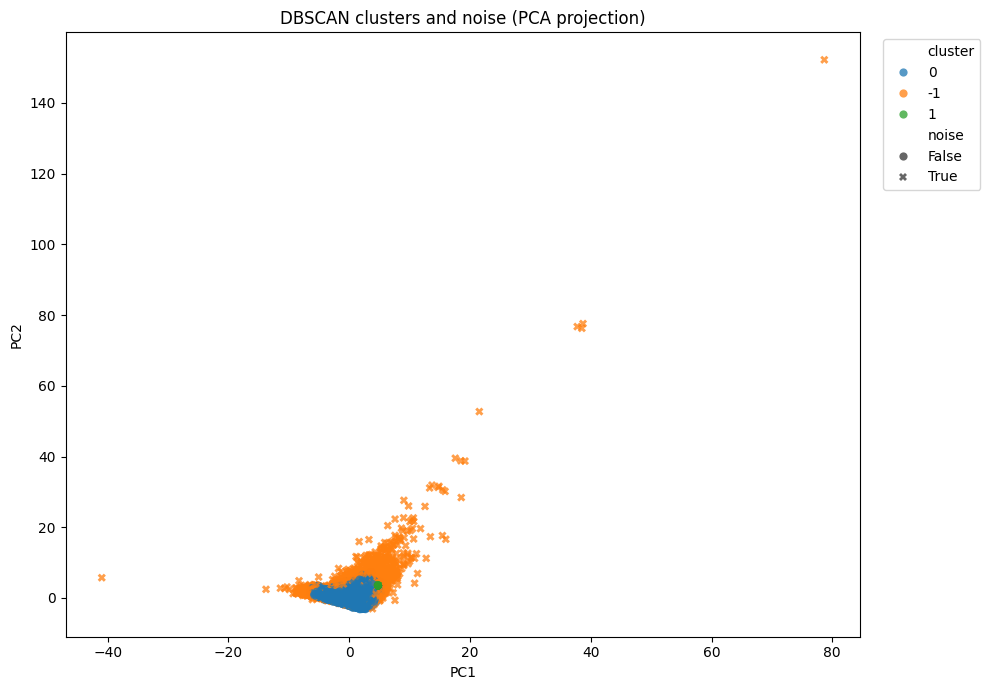

In [11]:
# PCA projection for visual inspection (PCA is not used to fit DBSCAN)
from sklearn.decomposition import PCA

if len(X_scaled) >= 3:
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
    plot_df = pd.DataFrame({
        "PC1": coords[:, 0], "PC2": coords[:, 1],
        "cluster": df["dbscan_cluster"].astype(str).to_numpy(),
        "noise": df["is_dbscan_noise"].to_numpy()
    })
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster",
                    style="noise", s=35, alpha=.75, linewidth=0)
    plt.title("DBSCAN clusters and noise (PCA projection)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [12]:
# Export review-ready outputs
OUT_ALL = "flyrank_dbscan_content_clusters.csv"
OUT_NOISE = "flyrank_dbscan_noise_review.csv"
OUT_SENSITIVITY = "flyrank_dbscan_eps_sensitivity.csv"

df.to_csv(OUT_ALL, index=False)
noise_df.to_csv(OUT_NOISE, index=False)
sensitivity_df.to_csv(OUT_SENSITIVITY, index=False)
print("Saved:", OUT_ALL, OUT_NOISE, OUT_SENSITIVITY)

try:
    from google.colab import files as colab_files
    for filename in [OUT_ALL, OUT_NOISE, OUT_SENSITIVITY]:
        colab_files.download(filename)
except Exception as exc:
    print("Automatic browser downloads unavailable in this environment:", exc)

Saved: flyrank_dbscan_content_clusters.csv flyrank_dbscan_noise_review.csv flyrank_dbscan_eps_sensitivity.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpretation checklist

- `dbscan_cluster == -1` means the observation lies outside a dense cluster for the selected settings.
- Check original impressions, clicks, CTR, ranking position, position volatility, and query-mix signals before deciding why it is unusual.
- Compare the chosen `eps`, `min_samples`, cluster count, and noise percentage across runs.
- Different clients can have different distributions. Consider per-client DBSCAN or client-relative features as a follow-up.
- DBSCAN can use substantial memory. If the aggregated table is large, explore with `MAX_ROWS_FOR_DBSCAN = 50000`, then run the full table when feasible.
- The query-level data in this release does not by itself establish AI-referral traffic; do not label an anomaly as AI-driven without a validated signal.